In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    AveragePooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
os.makedirs("EPS_Figures", exist_ok=True)

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 360s 2us/step
Training Images : (50000, 32, 32, 3)
Testing Images  : (10000, 32, 32, 3)


In [4]:
classes = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

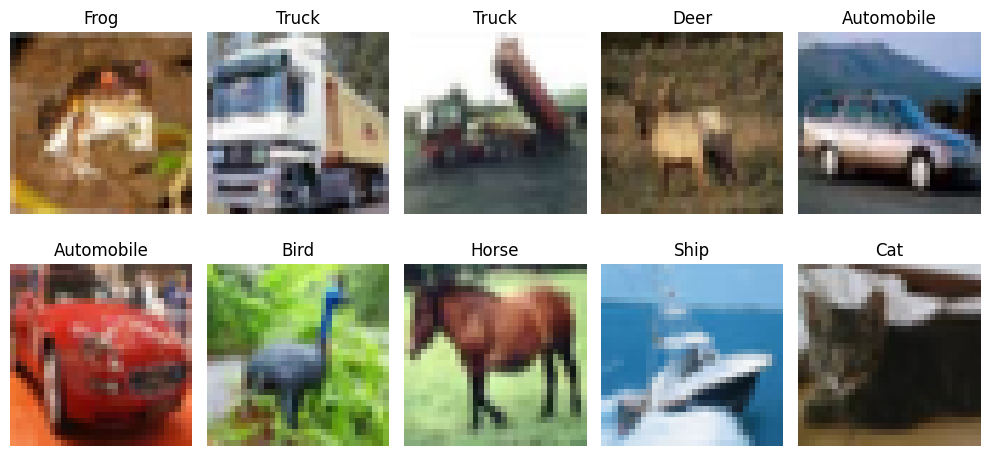

In [5]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(classes[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.savefig("EPS_Figures/sample_images.eps", format='eps', dpi=600)
plt.show()

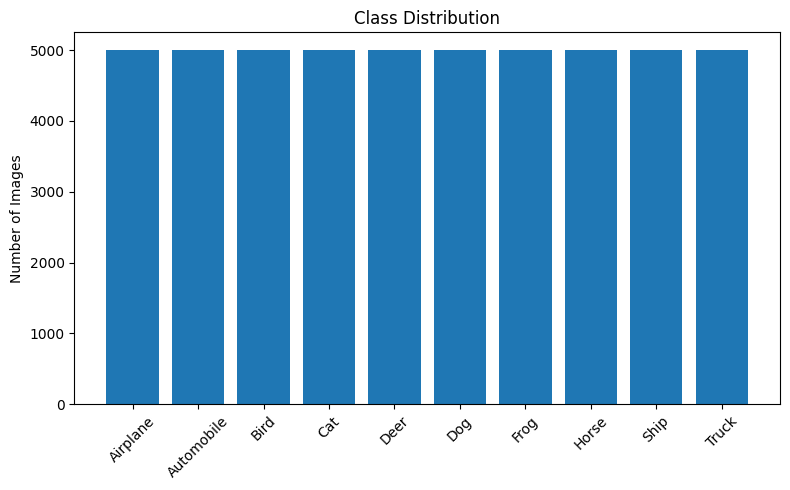

In [6]:
counts = np.bincount(y_train.flatten())

plt.figure(figsize=(8,5))
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.tight_layout()

plt.savefig("EPS_Figures/class_distribution.eps",
            format='eps',
            dpi=600)

plt.show()

In [7]:
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [8]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [9]:
model = Sequential()

model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same',
    input_shape=(32,32,3)
))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 155ms/step - accuracy: 0.4103 - loss: 1.6067 - val_accuracy: 0.5579 - val_loss: 1.2400
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 152ms/step - accuracy: 0.5694 - loss: 1.2126 - val_accuracy: 0.6202 - val_loss: 1.0567
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 94s 151ms/step - accuracy: 0.6398 - loss: 1.0215 - val_accuracy: 0.6714 - val_loss: 0.9427
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 149ms/step - accuracy: 0.6836 - loss: 0.9034 - val_accuracy: 0.7018 - val_loss: 0.8502
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 143ms/step - accuracy: 0.7165 - loss: 0.8145 - val_accuracy: 0.7154 - val_loss: 0.8149
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 90s 144ms/step - accuracy: 0.7410 - loss: 0.7394 - val_accuracy: 0.7393 - val_loss: 0.7701
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 142ms/step - accuracy: 0.7615 - loss: 0.6775 - val_accuracy: 0.7305 - val_loss: 0.7863
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 146ms/step - accuracy: 0.7808 - lo

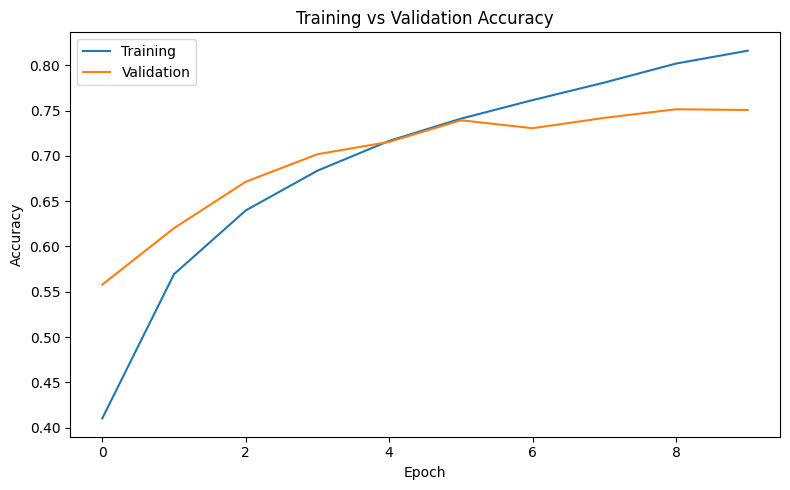

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label="Training")
plt.plot(history.history['val_accuracy'],label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()

plt.savefig("EPS_Figures/accuracy_curve.eps",
            format='eps',
            dpi=600)

plt.show()

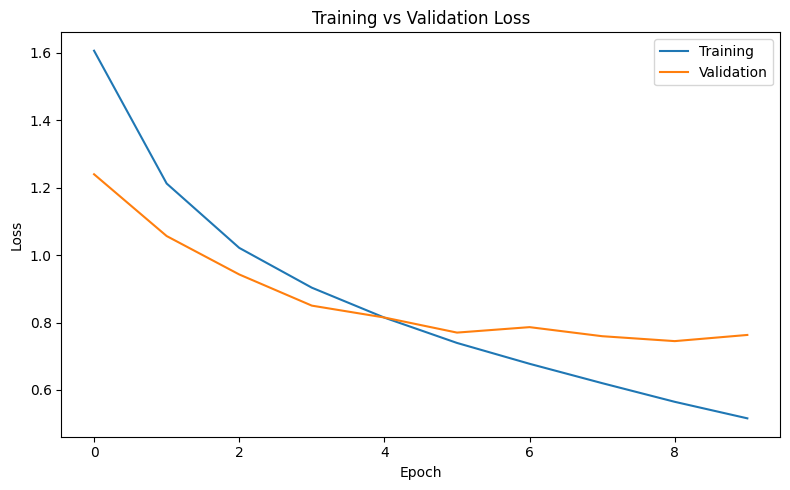

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label="Training")
plt.plot(history.history['val_loss'],label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.tight_layout()

plt.savefig("EPS_Figures/loss_curve.eps",
            format='eps',
            dpi=600)

plt.show()

In [14]:
loss, accuracy = model.evaluate(X_test,y_test_cat)

print("Test Accuracy :",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7472 - loss: 0.7867
Test Accuracy : 0.7472000122070312


In [15]:
prediction = model.predict(X_test)

y_pred = np.argmax(prediction,axis=1)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


In [16]:
prediction = model.predict(X_test)

y_pred = np.argmax(prediction,axis=1)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [17]:
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :",accuracy)
print("Precision :",precision)
print("Recall :",recall)
print("F1 Score :",f1)

Accuracy : 0.7472000122070312
Precision : 0.7508240998228785
Recall : 0.7472
F1 Score : 0.7461382975149471


In [18]:
print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

              precision    recall  f1-score   support

    Airplane       0.82      0.78      0.80      1000
  Automobile       0.90      0.79      0.84      1000
        Bird       0.76      0.57      0.65      1000
         Cat       0.56      0.59      0.57      1000
        Deer       0.69      0.71      0.70      1000
         Dog       0.66      0.64      0.65      1000
        Frog       0.79      0.82      0.80      1000
       Horse       0.73      0.84      0.78      1000
        Ship       0.86      0.86      0.86      1000
       Truck       0.74      0.88      0.80      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



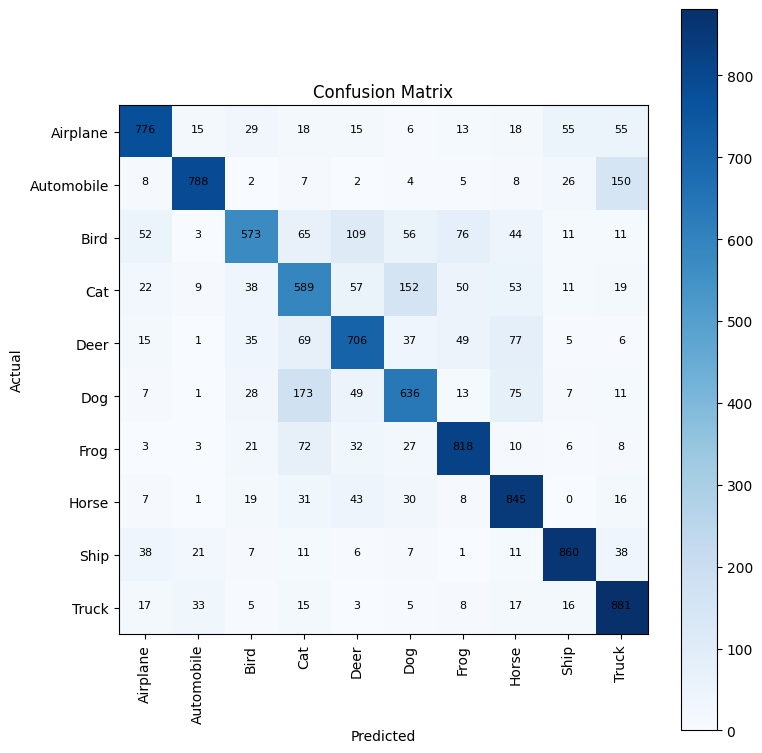

In [19]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,8))

plt.imshow(cm,cmap='Blues')

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(np.arange(10),classes,rotation=90)

plt.yticks(np.arange(10),classes)

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            color="black",
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    "EPS_Figures/confusion_matrix.eps",
    format='eps',
    dpi=600
)

plt.show()

In [20]:
feature_model = Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

feature_maps = feature_model.predict(X_test[:1])

print(feature_maps.shape)

feature_maps = feature_model.predict(
    X_test[:1]
)

print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
(1, 32, 32, 32)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
(1, 32, 32, 32)


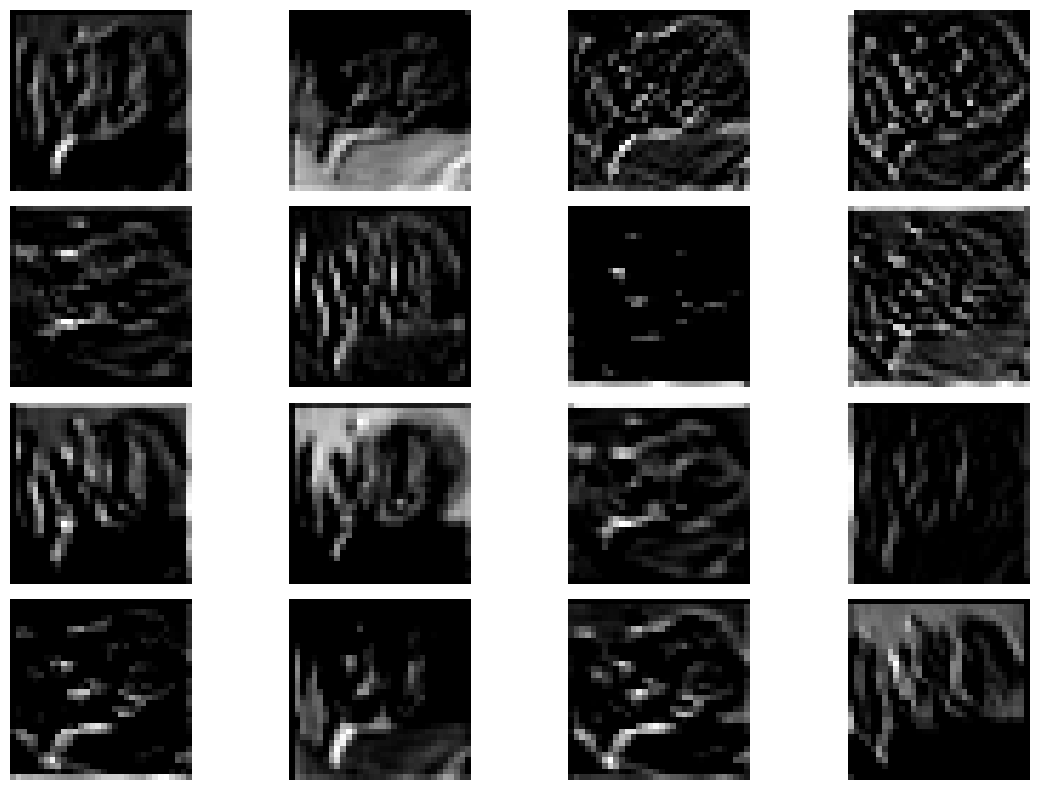

In [21]:
plt.figure(figsize=(12,8))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(feature_maps[0,:,:,i],
               cmap='gray')

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "EPS_Figures/feature_maps.eps",
    format='eps',
    dpi=600
)

plt.show()

In [22]:
max_model = Sequential([
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(10,activation='softmax')
])

max_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        72,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,906 (284.79 KB)

 Trainable params: 72,906 (284.79 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
max_model = Sequential([
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(10,activation='softmax')
])

max_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        72,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,906 (284.79 KB)

 Trainable params: 72,906 (284.79 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
for layer in model.layers:

    print("-----------------------------------")
    print("Layer :",layer.name)
    print("Trainable Parameters :",layer.count_params())

-----------------------------------
Layer : conv2d
Trainable Parameters : 896
-----------------------------------
Layer : max_pooling2d
Trainable Parameters : 0
-----------------------------------
Layer : conv2d_1
Trainable Parameters : 18496
-----------------------------------
Layer : max_pooling2d_1
Trainable Parameters : 0
-----------------------------------
Layer : conv2d_2
Trainable Parameters : 73856
-----------------------------------
Layer : max_pooling2d_2
Trainable Parameters : 0
-----------------------------------
Layer : flatten
Trainable Parameters : 0
-----------------------------------
Layer : dense
Trainable Parameters : 524544
-----------------------------------
Layer : dropout
Trainable Parameters : 0
-----------------------------------
Layer : dense_1
Trainable Parameters : 2570


In [25]:
results = []

batch_sizes = [32,64]
optimizers = ['adam','sgd']

for batch in batch_sizes:

    for opt in optimizers:

        temp_model = Sequential([
            Conv2D(32,(3,3),
            activation='relu',
            input_shape=(32,32,3)),
            MaxPooling2D((2,2)),
            Flatten(),
            Dense(10,
            activation='softmax')
        ])

        temp_model.compile(
            optimizer=opt,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        h = temp_model.fit(
            X_train,
            y_train_cat,
            epochs=3,
            batch_size=batch,
            validation_split=0.2,
            verbose=0
        )

        acc = h.history['val_accuracy'][-1]

        results.append(
            [opt,batch,acc]
        )

In [26]:
import pandas as pd

df = pd.DataFrame(
    results,
    columns=[
        "Optimizer",
        "Batch Size",
        "Validation Accuracy"
    ]
)

print(df)

  Optimizer  Batch Size  Validation Accuracy
0      adam          32               0.5825
1       sgd          32               0.4850
2      adam          64               0.5811
3       sgd          64               0.4229


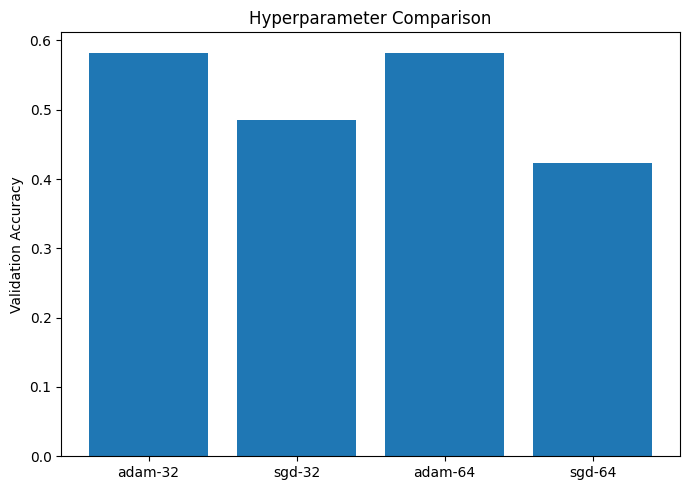

In [27]:
labels = [
    f"{r[0]}-{r[1]}"
    for r in results
]

accuracy = [
    r[2]
    for r in results
]

plt.figure(figsize=(7,5))

plt.bar(labels,accuracy)

plt.ylabel("Validation Accuracy")

plt.title("Hyperparameter Comparison")

plt.tight_layout()

plt.savefig(
    "EPS_Figures/hyperparameter_accuracy.eps",
    format='eps',
    dpi=600
)

plt.show()

In [28]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)

0 conv2d Conv2D
1 max_pooling2d MaxPooling2D
2 conv2d_1 Conv2D
3 max_pooling2d_1 MaxPooling2D
4 conv2d_2 Conv2D
5 max_pooling2d_2 MaxPooling2D
6 flatten Flatten
7 dense Dense
8 dropout Dropout
9 dense_1 Dense


In [29]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D

# Get outputs of all convolution layers
conv_outputs = []

for layer in model.layers:
    if isinstance(layer, Conv2D):
        conv_outputs.append(layer.output)

feature_model = Model(
    inputs=model.inputs,
    outputs=conv_outputs
)

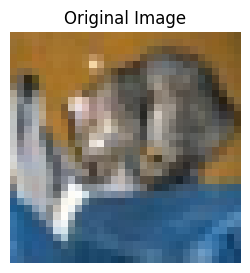

In [30]:
image = X_test[0]

plt.figure(figsize=(3,3))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [31]:
feature_maps = feature_model.predict(image[np.newaxis,...])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step


Convolution Layer 1
Feature Map Shape: (1, 32, 32, 32)


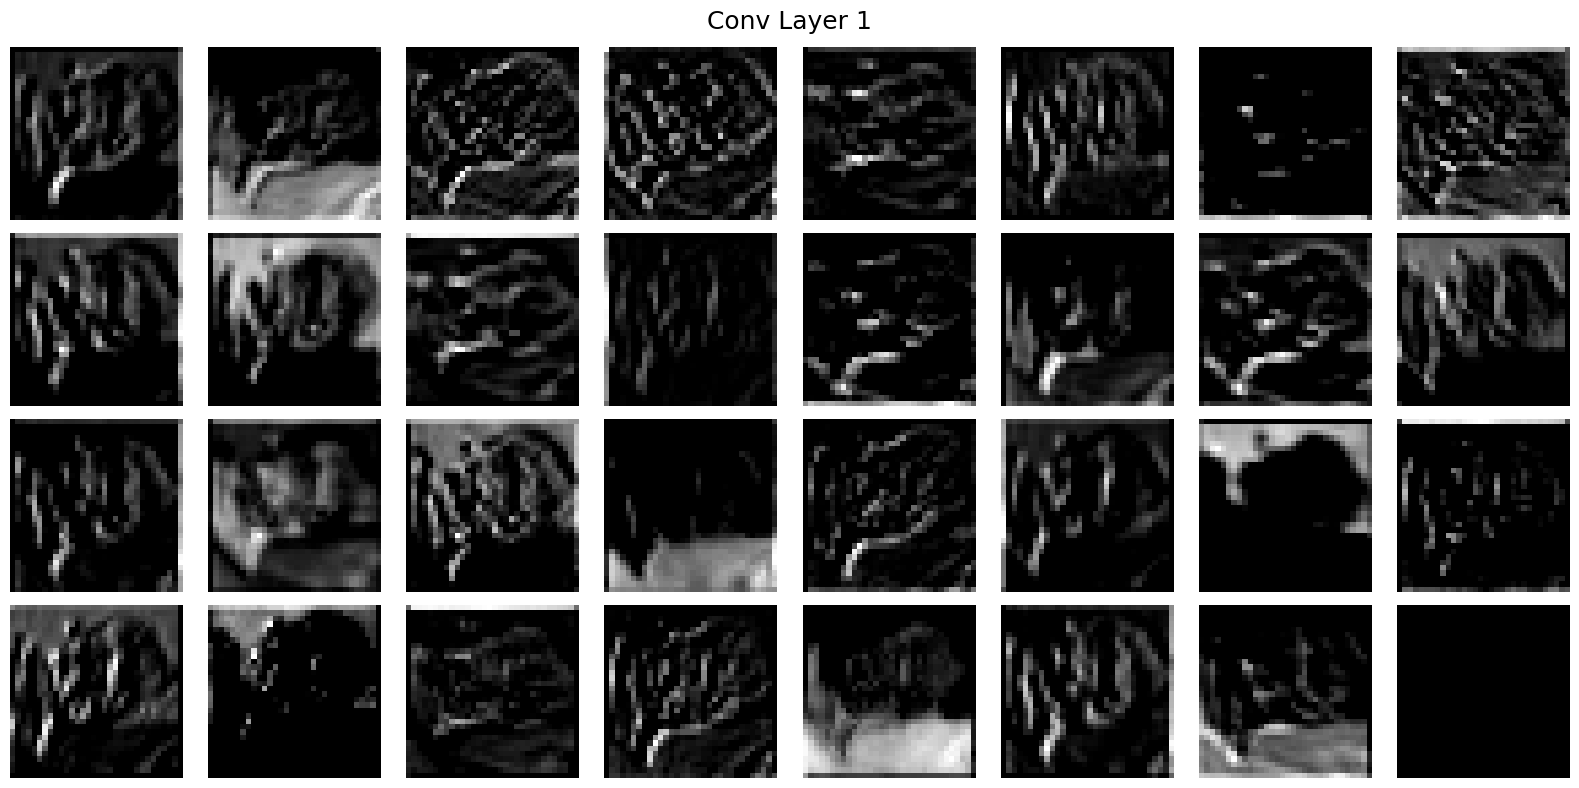

Convolution Layer 2
Feature Map Shape: (1, 16, 16, 64)


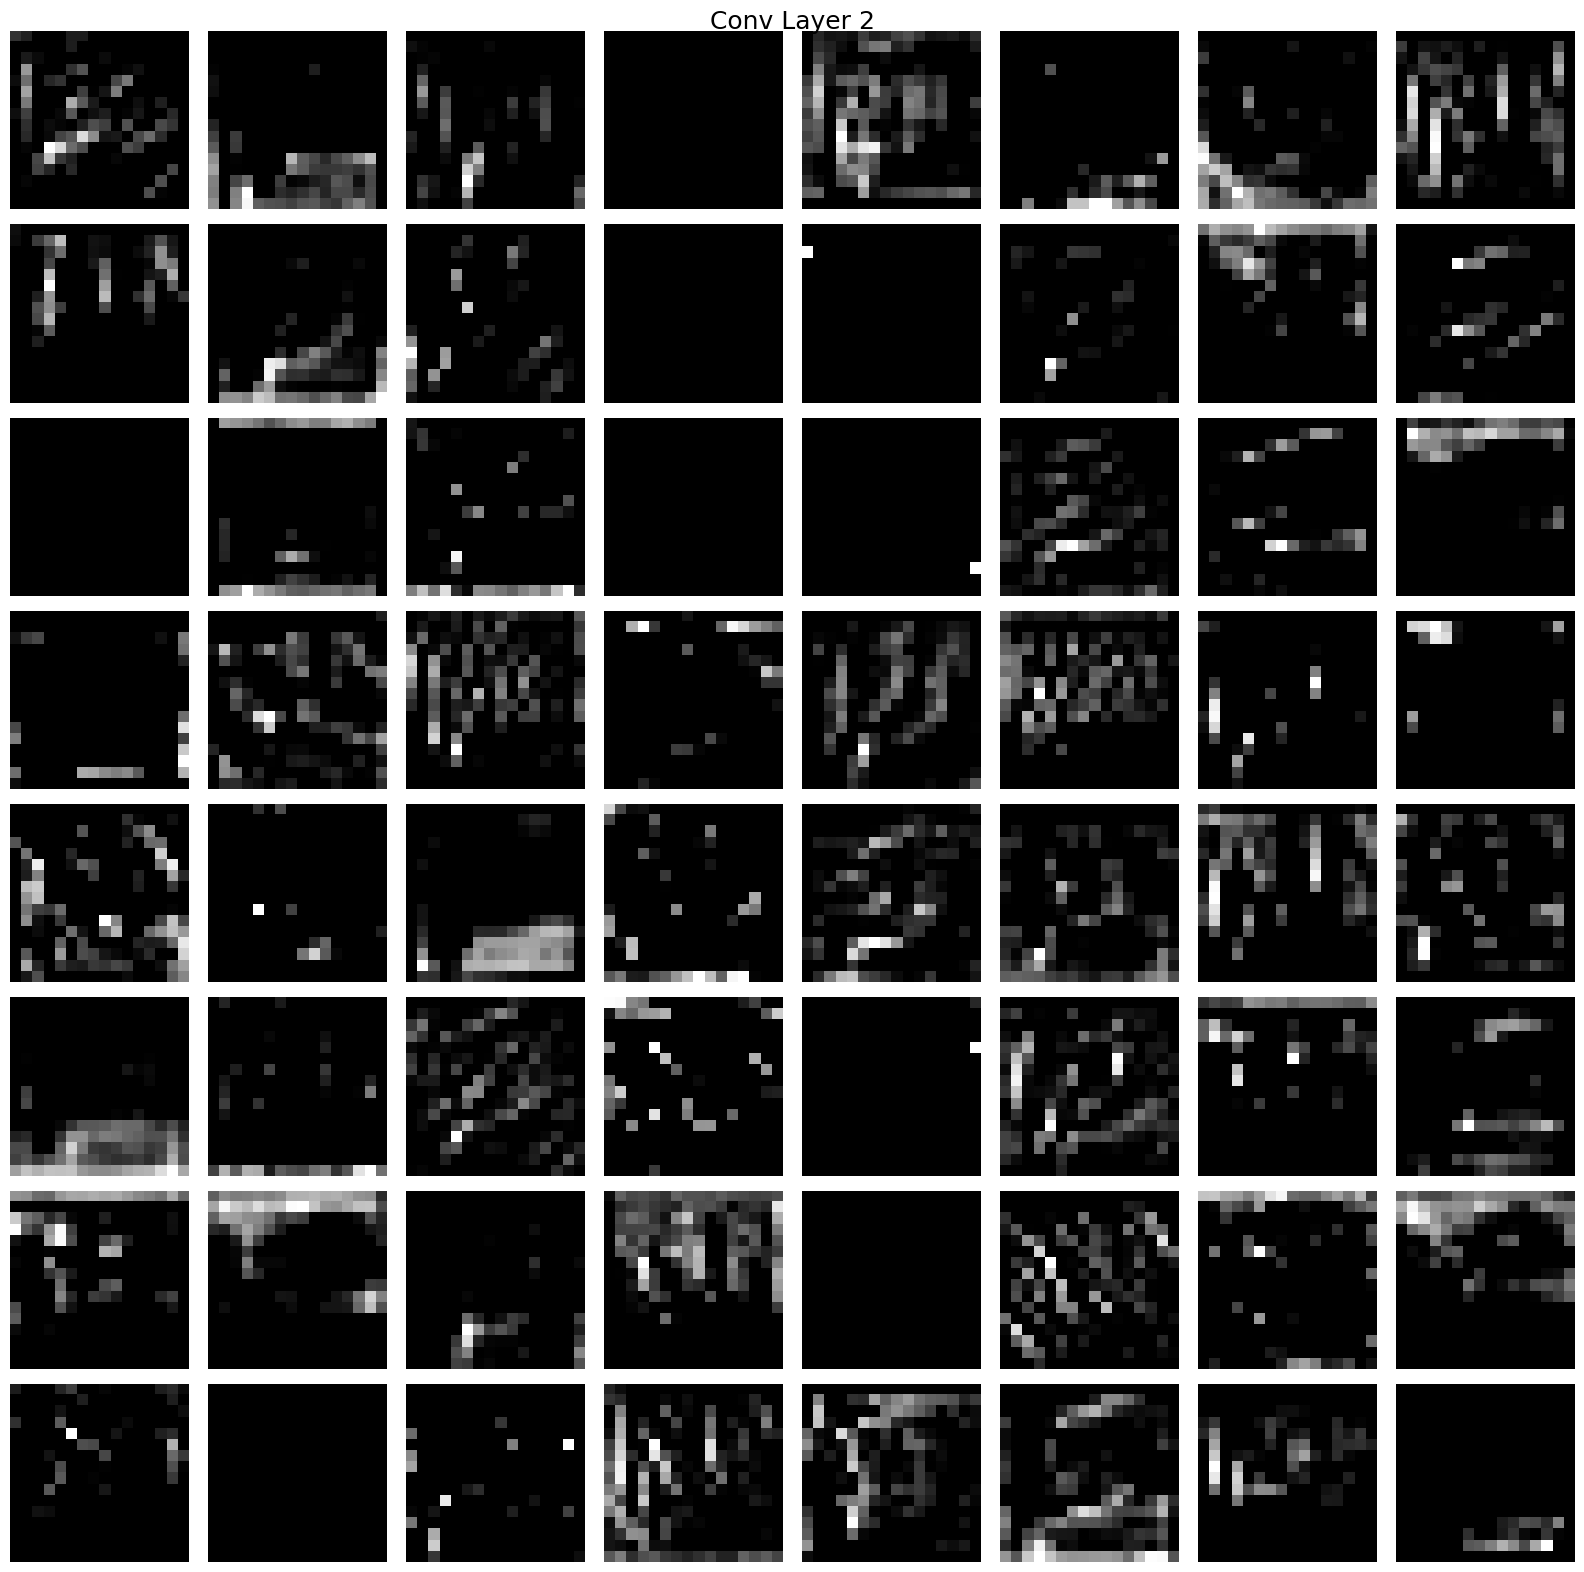

Convolution Layer 3
Feature Map Shape: (1, 8, 8, 128)


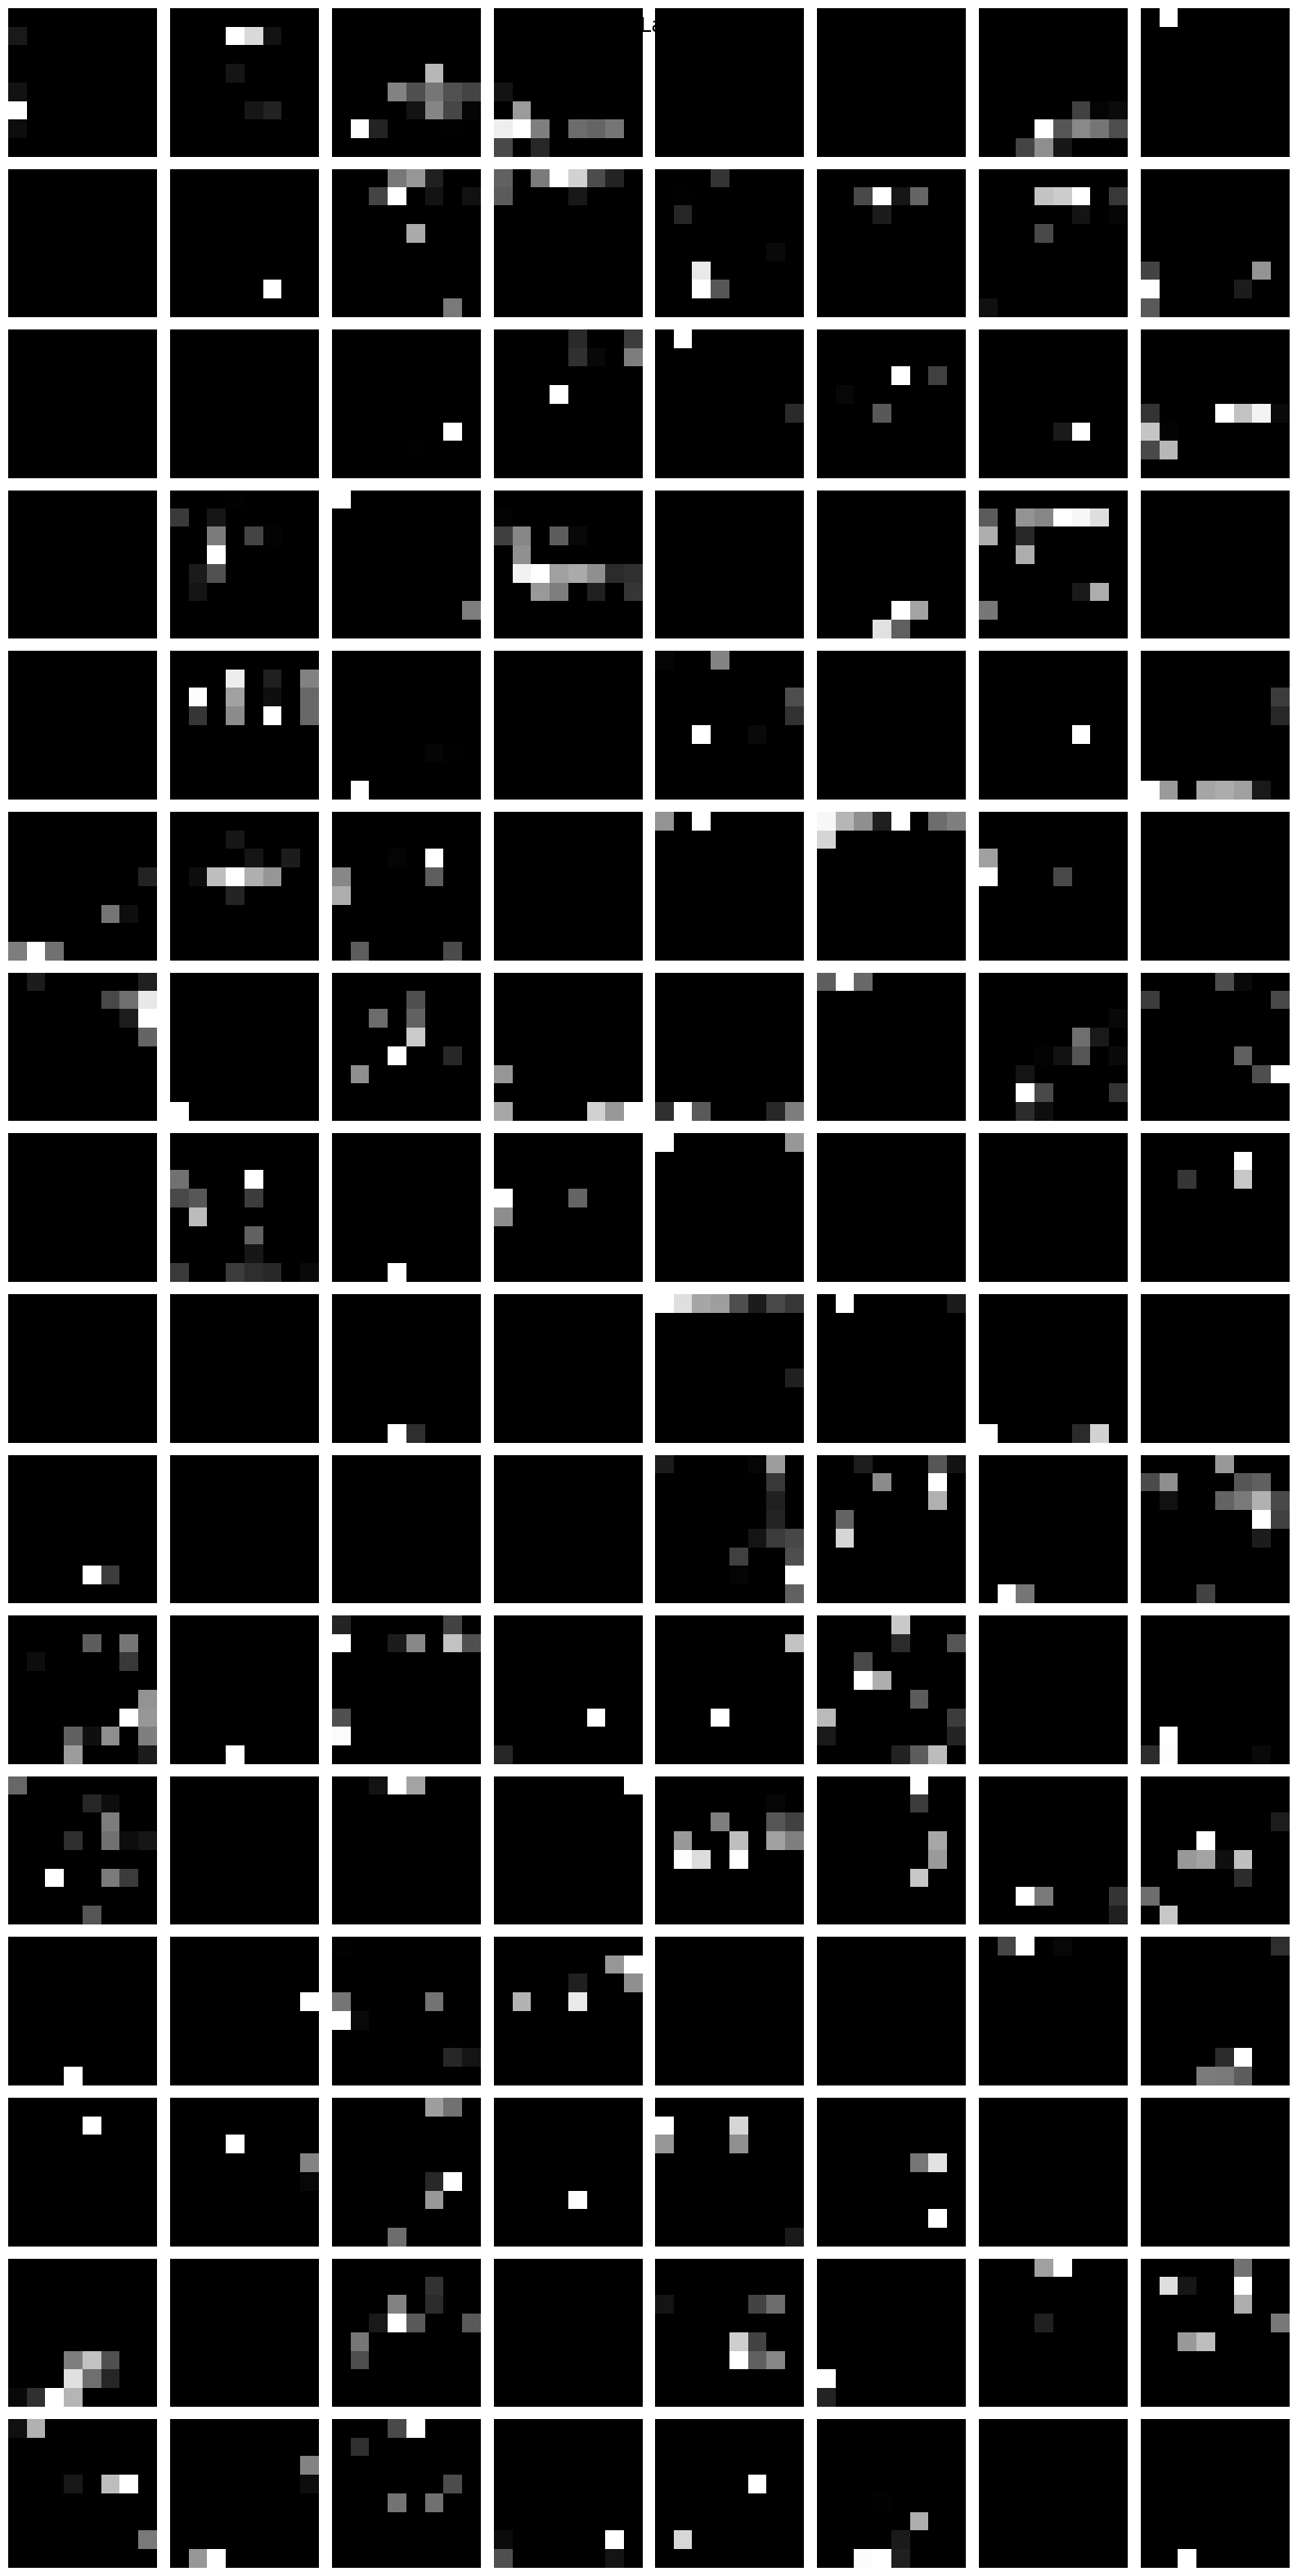

In [32]:
import math

for layer_num, fmap in enumerate(feature_maps):

    print("="*60)
    print("Convolution Layer", layer_num+1)
    print("Feature Map Shape:", fmap.shape)

    n_filters = fmap.shape[-1]

    cols = 8
    rows = math.ceil(n_filters / cols)

    plt.figure(figsize=(16, rows*2))

    for i in range(n_filters):

        plt.subplot(rows, cols, i+1)

        plt.imshow(fmap[0, :, :, i], cmap='gray')

        plt.axis('off')

    plt.suptitle(f"Conv Layer {layer_num+1}", fontsize=18)

    plt.tight_layout()

    plt.savefig(
        f"EPS_Figures/ConvLayer_{layer_num+1}_FeatureMaps.eps",
        format="eps",
        dpi=600
    )

    plt.show()

In [33]:
for layer_num, fmap in enumerate(feature_maps):

    for i in range(fmap.shape[-1]):

        plt.figure(figsize=(3,3))

        plt.imshow(fmap[0,:,:,i], cmap='gray')

        plt.axis('off')

        plt.savefig(
            f"EPS_Figures/Layer{layer_num+1}_Filter{i+1}.eps",
            format='eps',
            dpi=600,
            bbox_inches='tight'
        )

        plt.close()

In [34]:
for i, fmap in enumerate(feature_maps):
    print(f"Conv Layer {i+1}")
    print("Shape:", fmap.shape)

Conv Layer 1
Shape: (1, 32, 32, 32)
Conv Layer 2
Shape: (1, 16, 16, 64)
Conv Layer 3
Shape: (1, 8, 8, 128)


In [37]:
from google.colab import files
import shutil

# Create a ZIP file of the folder
shutil.make_archive("EPS_Figures", "zip", "EPS_Figures")

# Download the ZIP file
files.download("EPS_Figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Convolution Layer 1
Filter Shape: (3, 3, 3, 32)


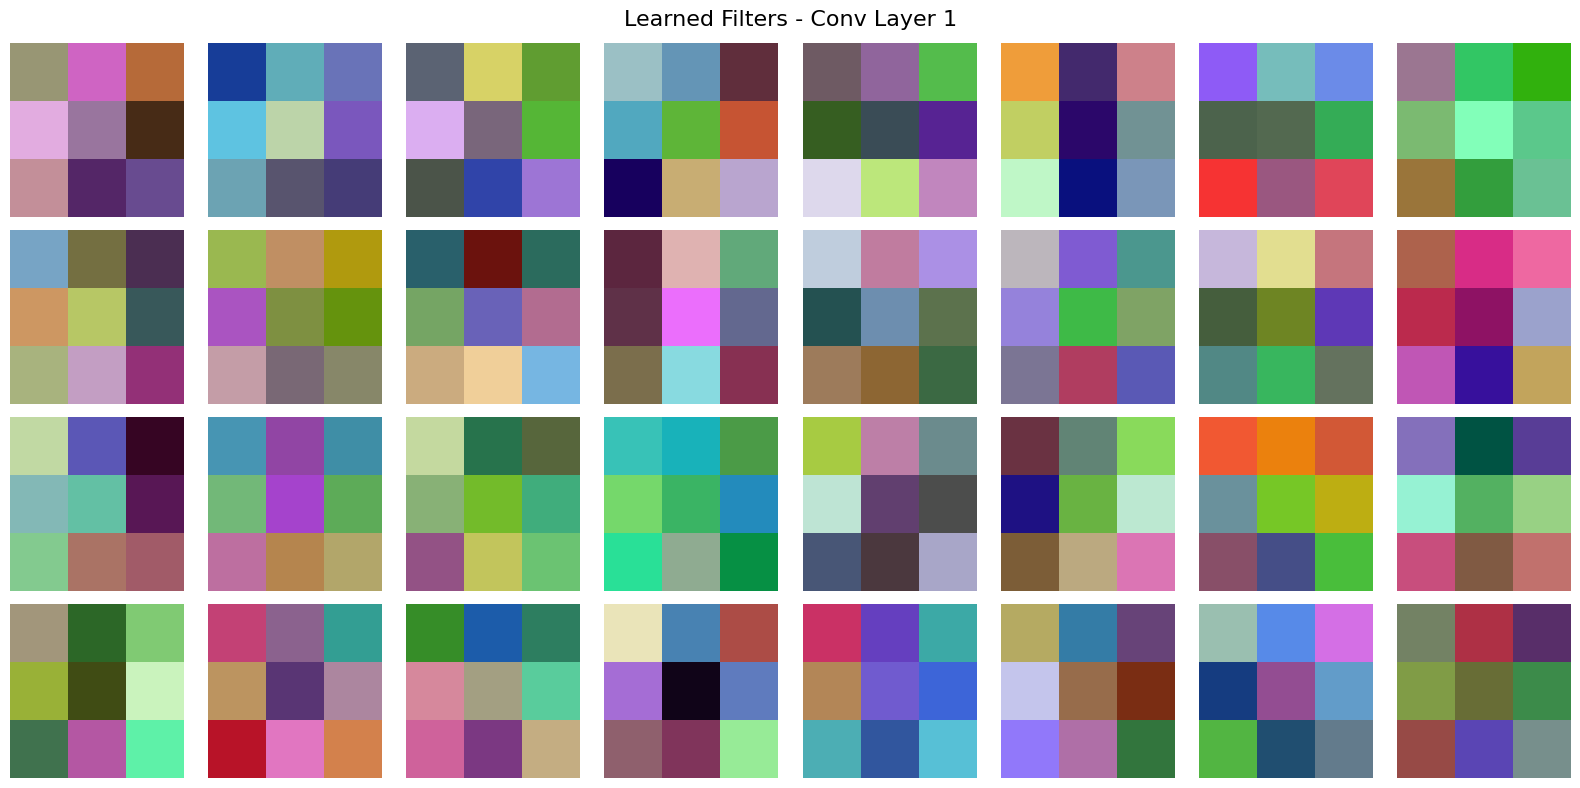

Convolution Layer 2
Filter Shape: (3, 3, 32, 64)


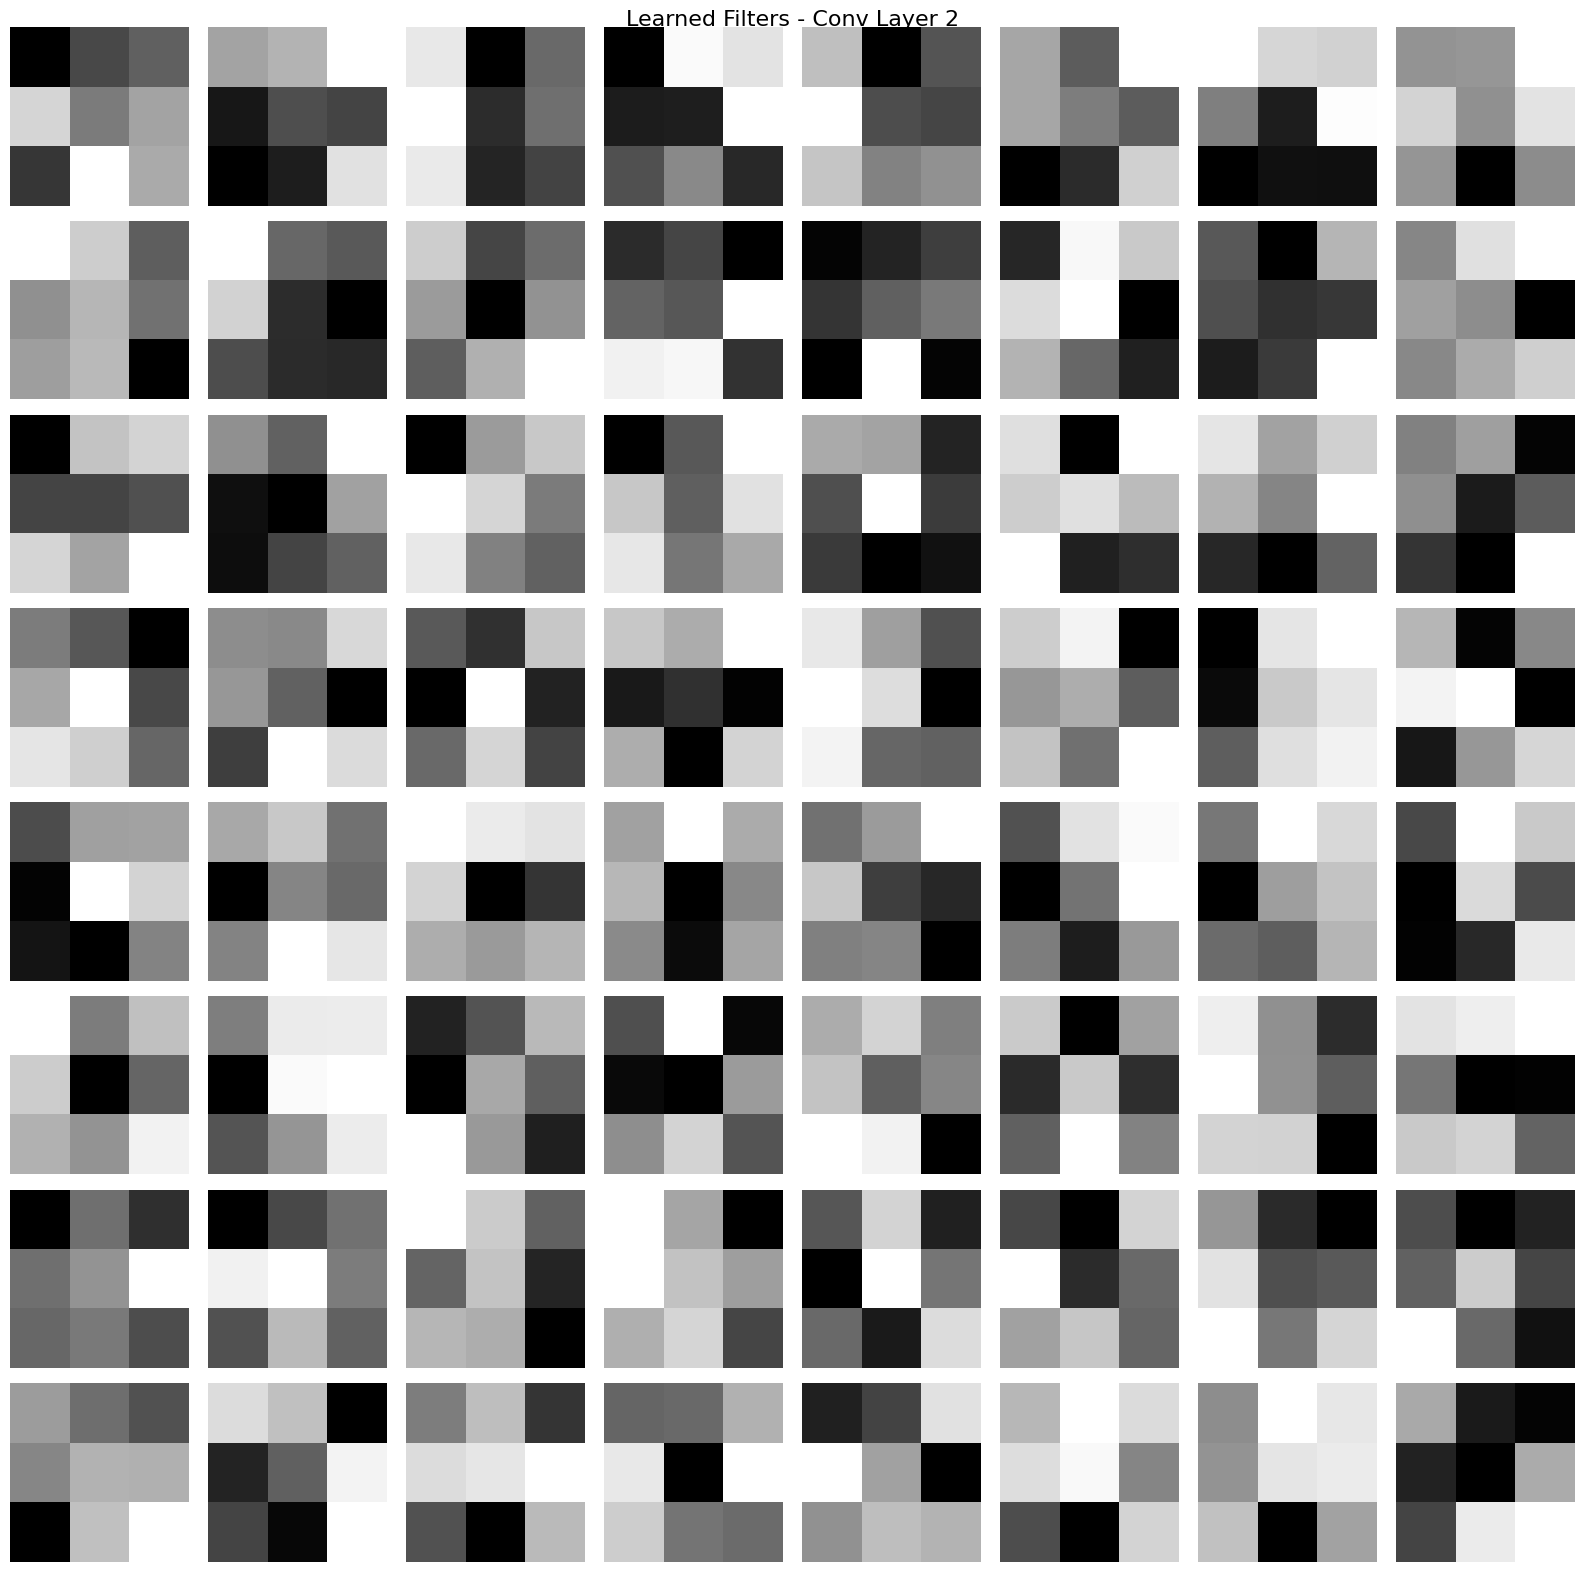

Convolution Layer 3
Filter Shape: (3, 3, 64, 128)


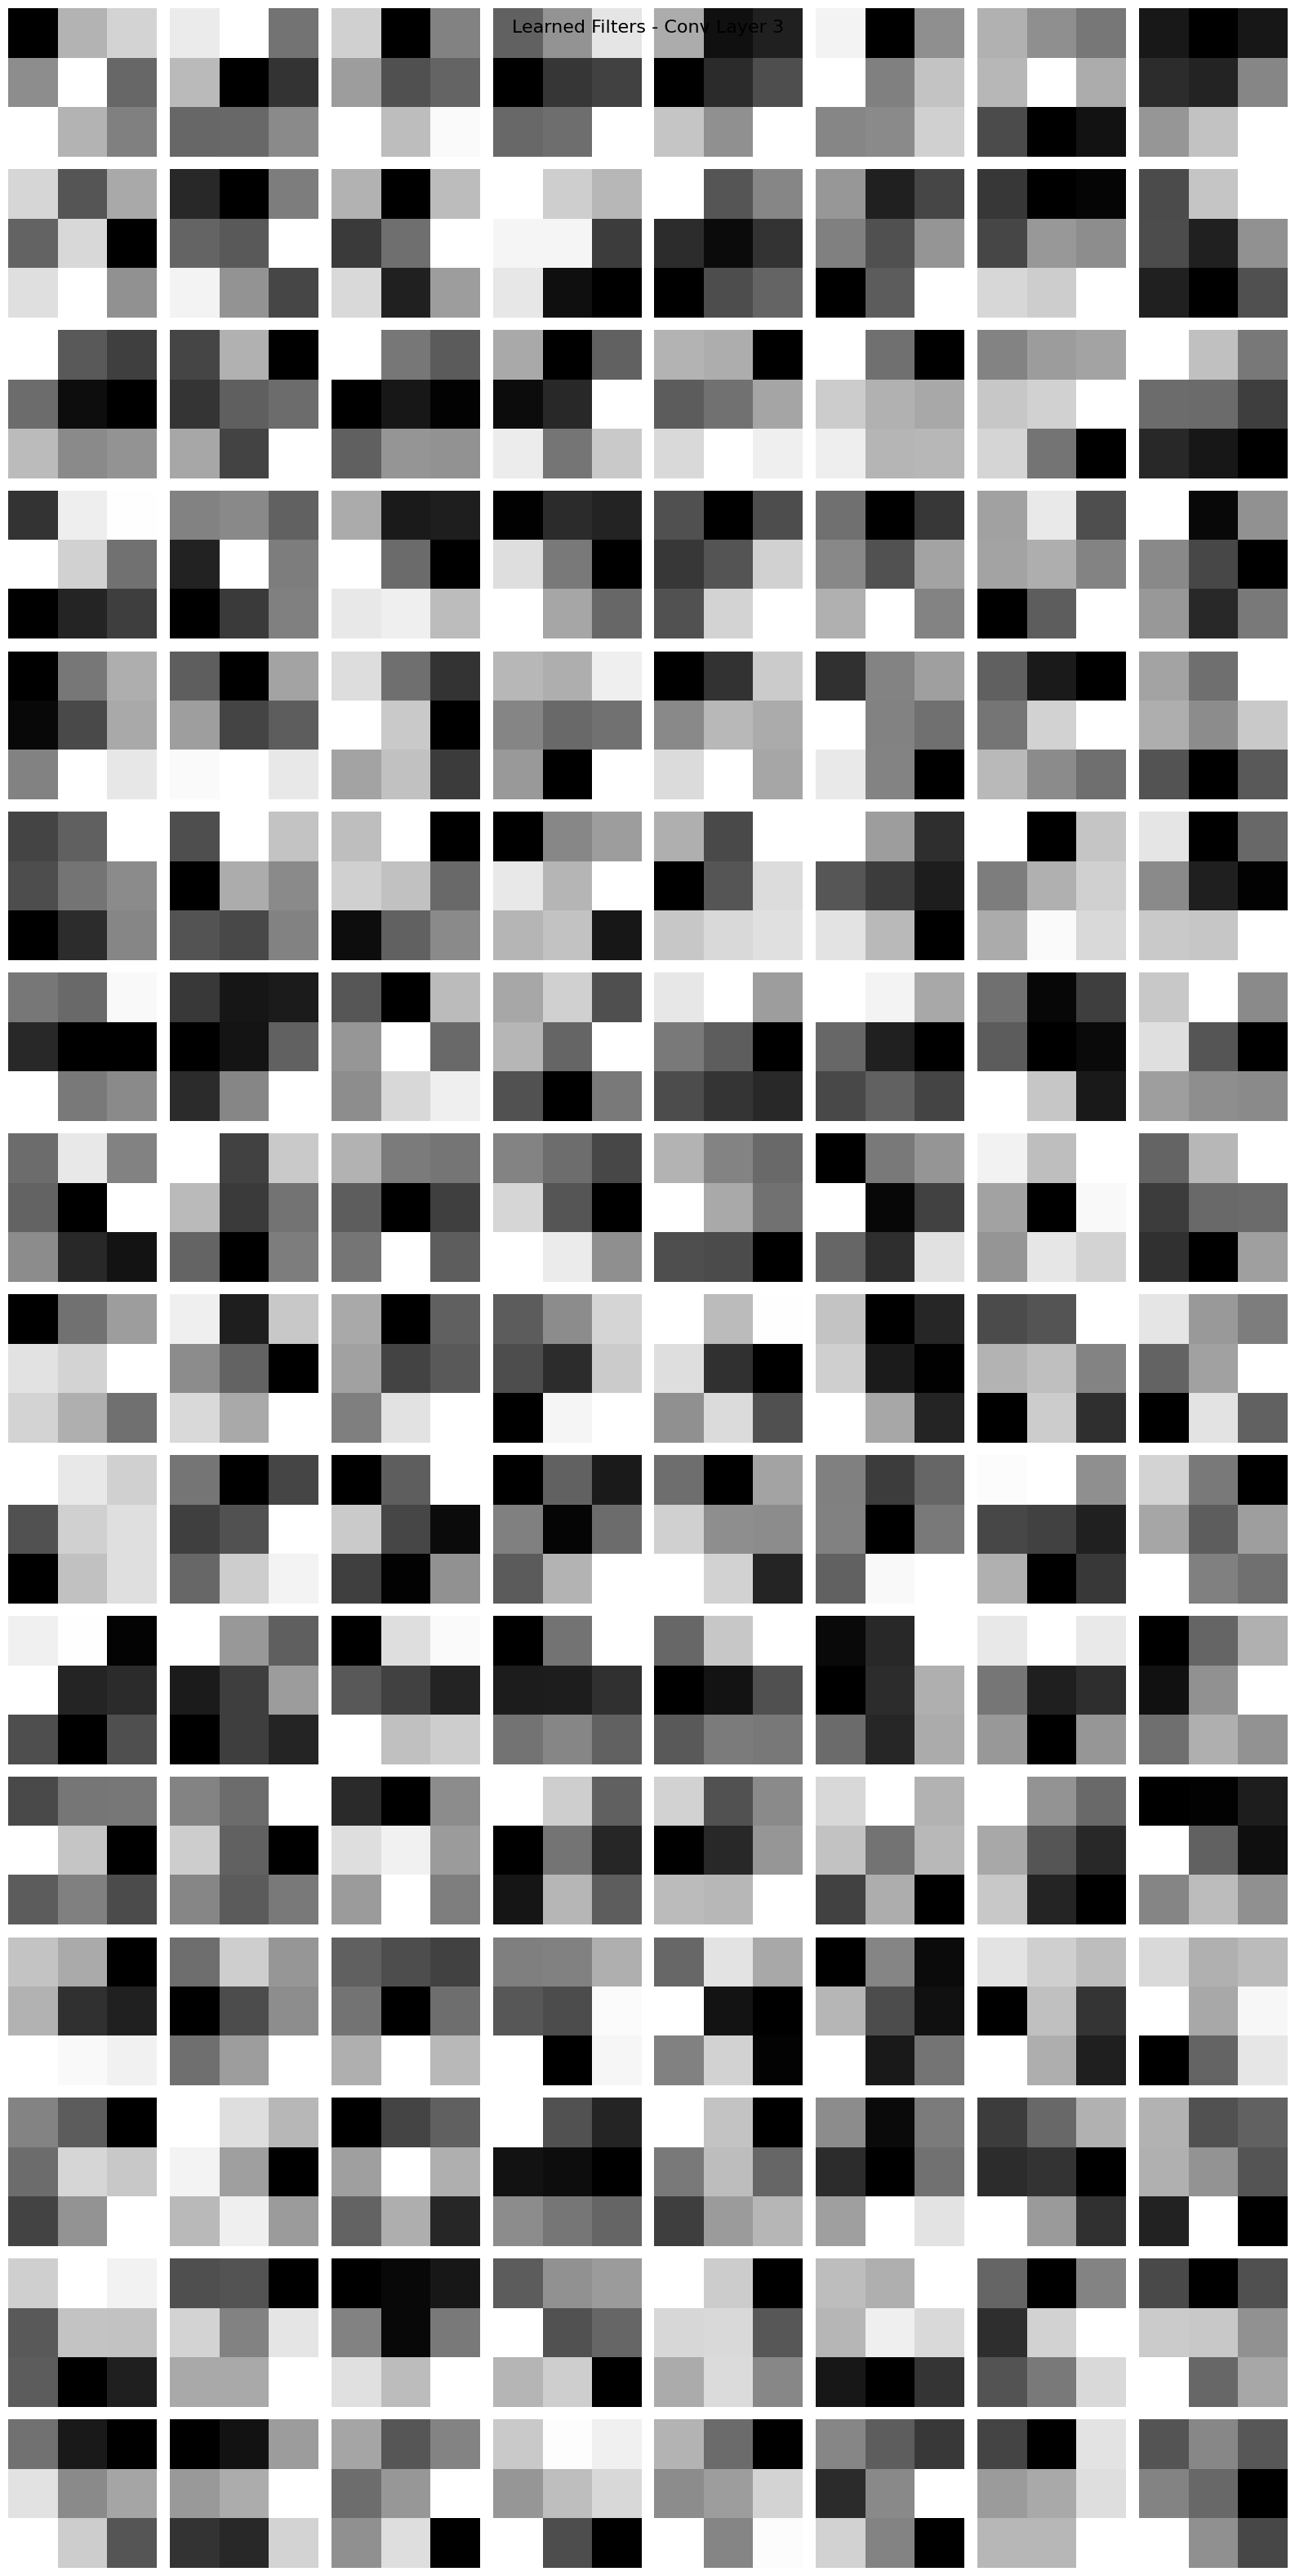

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import math
import os
from tensorflow.keras.layers import Conv2D

os.makedirs("EPS_Figures", exist_ok=True)

conv_layer_num = 1

for layer in model.layers:

    if isinstance(layer, Conv2D):

        # Get weights (filters)
        filters, biases = layer.get_weights()

        print("="*60)
        print(f"Convolution Layer {conv_layer_num}")
        print("Filter Shape:", filters.shape)

        # Normalize filters to [0,1] for visualization
        f_min, f_max = filters.min(), filters.max()
        filters = (filters - f_min) / (f_max - f_min + 1e-8)

        n_filters = filters.shape[3]      # Number of filters
        n_channels = filters.shape[2]     # RGB channels from previous layer

        cols = 8
        rows = math.ceil(n_filters / cols)

        plt.figure(figsize=(16, rows * 2))

        for i in range(n_filters):

            plt.subplot(rows, cols, i + 1)

            # -------- First Conv Layer (RGB filters) --------
            if n_channels == 3:
                plt.imshow(filters[:, :, :, i])

            # -------- Deeper Conv Layers --------
            else:
                # Display only first channel of each filter
                plt.imshow(filters[:, :, 0, i], cmap='gray')

            plt.axis('off')

        plt.suptitle(f"Learned Filters - Conv Layer {conv_layer_num}", fontsize=16)

        plt.tight_layout()

        plt.savefig(
            f"EPS_Figures/Learned_Filters_ConvLayer_{conv_layer_num}.eps",
            format="eps",
            dpi=600,
            bbox_inches='tight'
        )

        plt.show()

        conv_layer_num += 1